# Cost-Aware Predictive Autoscaling Using LSTM-Based Load Forecasting


**Architecture:**
- **Layer 1 — LSTM Forecasting Engine**: learns past CPU patterns and predicts future load
- **Layer 2 — Cost-Aware Decision Engine**: converts predictions into scaling actions with a cost penalty function
- **Layer 3 — Cloud Simulation**: replays decisions through a simulated server farm and measures SLA / cost metrics

We compare against a classic **Reactive (threshold-based) autoscaler** as our baseline.

> **Demand Scaling Note**: The raw dataset records CPU % for a single machine (3–10 %).  
> We multiply by `DEMAND_SCALE = 20` to model *aggregate request load* across a virtual service tier,  
> giving demand in the range 60–200 % and requiring 1–3 servers to service it.

---
**Phase 2A update (this run):** fixed a train/test scaler-leakage bug in `scale_and_split` (the `MinMaxScaler` was being fit on the whole series, test period included, before the split) and added a naive persistence baseline so the LSTM's RMSE has something honest to be compared against. The model was retrained from scratch under the corrected preprocessing. See `outputs/phase2a_summary.json` for a before/after comparison.

---
## 0. Imports and Global Configuration

In [1]:
# Standard libraries for data handling, numerics, plotting
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque
from dataclasses import dataclass, field
from typing import List, Tuple

# Machine-learning helpers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow / Keras for the neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

# Fix random seeds so results are reproducible every run
np.random.seed(42)
tf.random.set_seed(42)

# Folder for all output PNGs
os.makedirs('outputs', exist_ok=True)

# ── Global simulation knob ───────────────────────────────────────────────────
# The raw CPU % for this machine is 3–10 %.  Multiplying by DEMAND_SCALE
# turns it into an *aggregate service-tier load* that ranges 60–200 %,
# making autoscaling decisions meaningful (1–3 servers required).
DEMAND_SCALE = 20.0
# ────────────────────────────────────────────────────────────────────────────

print(f"TensorFlow: {tf.__version__}")
print(f"Devices: {tf.config.list_physical_devices()}")
print("Setup complete.")

I0000 00:00:1787692811.221039    5607 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787692811.413409    5607 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787692814.270878    5607 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Setup complete.


---
## Layer 1 — LSTM Forecasting Engine
### Step 1.1: Load the Dataset

In [2]:
# Path to the raw CSV on disk (adjust if needed)
DATA_PATH = os.path.expanduser('~/Desktop/machine_usage_bigger.csv')

# Read only the first 500,000 rows to keep training fast
# (the full file has ~95 million rows — this sample is enough)
print("Loading 500,000 rows...")
df_raw = pd.read_csv(
    DATA_PATH,
    nrows=500_000,
    usecols=['machine_id', 'time_stamp', 'cpu_util_percent', 'mem_util_percent']
)
print(f"Shape: {df_raw.shape}  |  Unique machines: {df_raw['machine_id'].nunique()}")
df_raw.head()

Loading 500,000 rows...


Shape: (500000, 4)  |  Unique machines: 74


,machine_id,time_stamp,cpu_util_percent,mem_util_percent
0,m_1932,386640,41.0,92
1,m_1932,386670,43.0,92
2,m_1932,386690,44.0,92
3,m_1932,386800,46.0,92
4,m_1932,386930,44.0,93


### Step 1.2: Pick the Best Machine and Resample to 5-Minute Intervals

In [3]:
def pick_best_machine(df: pd.DataFrame) -> str:
    """Return the machine_id that has the most rows in the sample.
    More rows = more training data = better LSTM patterns."""
    counts = df['machine_id'].value_counts()
    best   = counts.idxmax()
    print(f"Best machine: {best}  ({counts[best]:,} rows)")
    return best


def prepare_timeseries(df: pd.DataFrame, machine_id: str) -> pd.DataFrame:
    """Filter to one machine, convert Unix timestamps to real datetimes,
    resample to one reading every 5 minutes (average within each bucket),
    and fill any gaps with the last known value."""
    mdf = df[df['machine_id'] == machine_id].copy()
    mdf['time_stamp'] = pd.to_datetime(mdf['time_stamp'], unit='s')
    mdf = mdf.set_index('time_stamp').sort_index()
    mdf = mdf[['cpu_util_percent', 'mem_util_percent']]
    mdf = mdf.resample('5min').mean()       # one row per 5 minutes
    mdf = mdf.ffill().dropna()              # fill gaps, remove remaining NaNs
    print(f"Series length: {len(mdf):,} points  |  "
          f"{mdf.index[0]}  →  {mdf.index[-1]}")
    return mdf


best_machine = pick_best_machine(df_raw)
ts           = prepare_timeseries(df_raw, best_machine)
ts.describe()

Best machine: m_1933  (7,193 rows)
Series length: 2,304 points  |  1970-01-01 00:00:00  →  1970-01-08 23:55:00


,cpu_util_percent,mem_util_percent
count,2304.000000,2304.000000
mean,5.682814,92.469277
std,0.954106,0.650913
min,3.000000,91.000000
25%,5.000000,92.000000
50%,5.750000,92.800000
75%,6.333333,93.000000
max,10.000000,94.000000


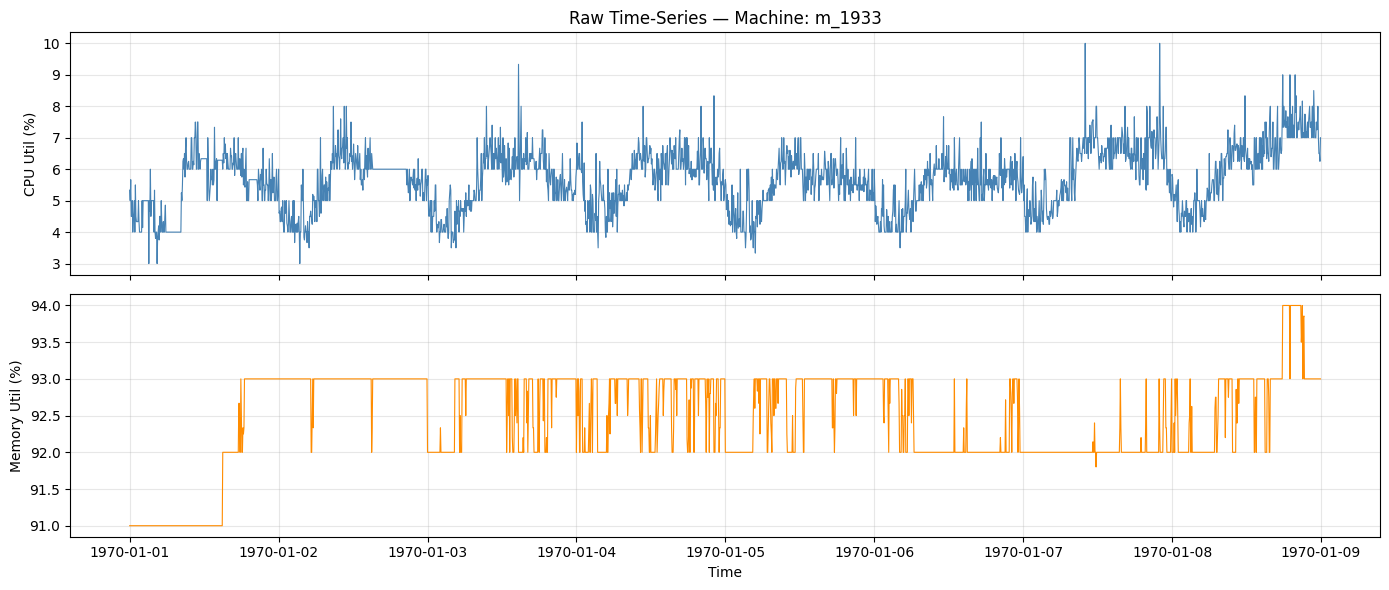

Saved → outputs/01_raw_timeseries.png


In [4]:
# Visualise raw CPU and memory so we can see what the LSTM will learn
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(ts.index, ts['cpu_util_percent'], color='steelblue', lw=0.8)
axes[0].set_ylabel('CPU Util (%)')
axes[0].set_title(f'Raw Time-Series — Machine: {best_machine}')
axes[0].grid(alpha=0.3)

axes[1].plot(ts.index, ts['mem_util_percent'], color='darkorange', lw=0.8)
axes[1].set_ylabel('Memory Util (%)')
axes[1].set_xlabel('Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/01_raw_timeseries.png', dpi=150)
plt.show()
print("Saved → outputs/01_raw_timeseries.png")

### Step 1.3: Build Sliding-Window Sequences

In [5]:
# --- LSTM window sizes ---
LOOKBACK_STEPS = 6    # 6 × 5 min = look back 30 minutes
HORIZON_STEPS  = 3    # 3 × 5 min = predict 15 minutes ahead
FEATURE_COL    = 'cpu_util_percent'


def scale_and_split(ts: pd.DataFrame, feature: str, test_ratio: float = 0.2):
    """Split chronologically FIRST, then fit the scaler on the TRAINING
    partition only, and use that same scaler to transform both train and
    test.

    Phase 2A fix: the previous version called `scaler.fit_transform()` on
    the whole series (train+test together) before splitting, which leaks
    the test period's min/max statistics into the normalisation applied to
    the training data -- a textbook train/test leakage bug. Fitting on
    train_raw only, and only transforming test with that already-fit
    scaler, removes that leak."""
    values = ts[[feature]].values.astype(np.float32)
    split  = int(len(values) * (1 - test_ratio))
    train_raw, test_raw = values[:split], values[split:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_raw)                     # fit on TRAIN ONLY
    train_data = scaler.transform(train_raw)
    test_data  = scaler.transform(test_raw)
    print(f"Train: {len(train_data):,} pts  |  Test: {len(test_data):,} pts")
    return train_data, test_data, scaler


def make_sequences(data: np.ndarray, lookback: int, horizon: int):
    """Slide a window across the scaled data to produce (X, y) pairs.
    X = the past 'lookback' steps (the history the LSTM sees).
    y = the next 'horizon' steps (what we want it to predict)."""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


train_data, test_data, scaler = scale_and_split(ts, FEATURE_COL)
X_train, y_train = make_sequences(train_data, LOOKBACK_STEPS, HORIZON_STEPS)
X_test,  y_test  = make_sequences(test_data,  LOOKBACK_STEPS, HORIZON_STEPS)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")


Train: 1,843 pts  |  Test: 461 pts
X_train: (1835, 6, 1)  y_train: (1835, 3)
X_test : (453, 6, 1)   y_test : (453, 3)


### Step 1.4: Build and Train the LSTM

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,531 (775.51 KB)

 Trainable params: 198,531 (775.51 KB)

 Non-trainable params: 0 (0.00 B)

...

16/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0071

19/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0072

23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0073

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0073 - val_loss: 0.0076


Restoring model weights from the end of the best epoch: 60.


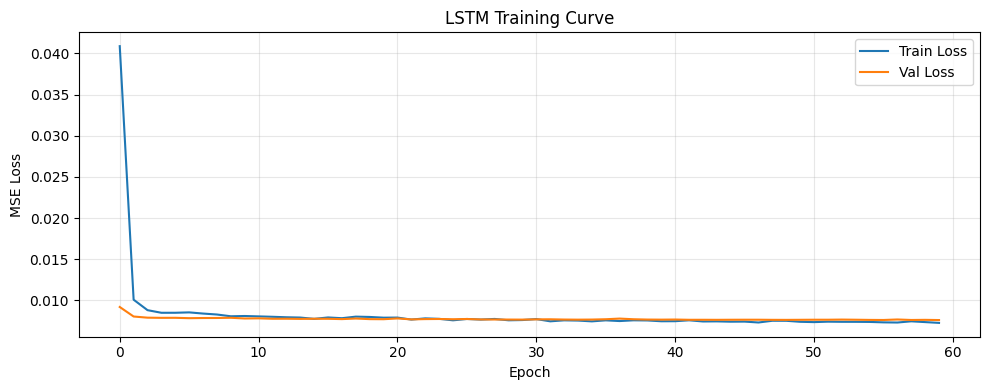

Saved → outputs/02_training_loss.png


In [6]:
def build_lstm_model(lookback: int, horizon: int) -> tf.keras.Model:
    """Two-layer LSTM with 128 units each and 20 % dropout.
    - Layer 1 returns its output at every time step so Layer 2 can see the full sequence.
    - Dropout prevents the network from memorising the training data (overfitting).
    - The final Dense layer maps to the 'horizon' future values we want."""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(128, return_sequences=False),
        Dropout(0.2),
        Dense(horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    model.summary()
    return model


MODEL_PATH = 'lstm_model.keras'

# Phase 2A: the scaler fix above changes what the model is trained on, so a
# model cached from before the fix is no longer valid for this pipeline.
# Always retrain here rather than silently reloading a stale cached model.
if os.path.exists(MODEL_PATH):
    print("Found a previously saved model, but preprocessing changed (leakage fix) "
          "-- retraining from scratch instead of reloading it.")

lstm_model = build_lstm_model(LOOKBACK_STEPS, HORIZON_STEPS)

# Stop if validation loss hasn't improved for 10 epochs in a row
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)
# Always save the best-so-far weights during training
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_loss',
                             save_best_only=True, verbose=0)

print("Training LSTM...")
history = lstm_model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot the training curve to check for overfitting
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('LSTM Training Curve')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('outputs/02_training_loss.png', dpi=150)
plt.show()
print("Saved → outputs/02_training_loss.png")


### Step 1.5: Evaluate — Predicted vs Actual

In [7]:
def evaluate_lstm(model, X_test, y_test, scaler):
    """Run the model on unseen test data, undo the 0-1 scaling to get
    real CPU % values, and compute RMSE + MAE (average prediction error in %)."""
    y_pred_scaled = model.predict(X_test, verbose=0)

    def inv(arr):
        # arr shape: (samples, horizon) -- invert each horizon column separately
        out = np.zeros_like(arr)
        for h in range(arr.shape[1]):
            out[:, h] = scaler.inverse_transform(
                arr[:, h].reshape(-1, 1)).flatten()
        return out

    y_pred_real = inv(y_pred_scaled)
    y_test_real = inv(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_real.flatten(), y_pred_real.flatten()))
    mae  = mean_absolute_error(y_test_real.flatten(), y_pred_real.flatten())
    print(f"Test RMSE: {rmse:.4f} percentage points")
    print(f"Test MAE : {mae:.4f} percentage points")
    return y_pred_real, y_test_real, rmse, mae


y_pred_real, y_test_real, rmse, mae = evaluate_lstm(lstm_model, X_test, y_test, scaler)
print(f"\nLSTM RMSE = {rmse:.4f}%  |  LSTM MAE = {mae:.4f}%  (forecast error in raw CPU %)")


Test RMSE: 0.5778 percentage points
Test MAE : 0.4370 percentage points

LSTM RMSE = 0.5778%  |  LSTM MAE = 0.4370%  (forecast error in raw CPU %)


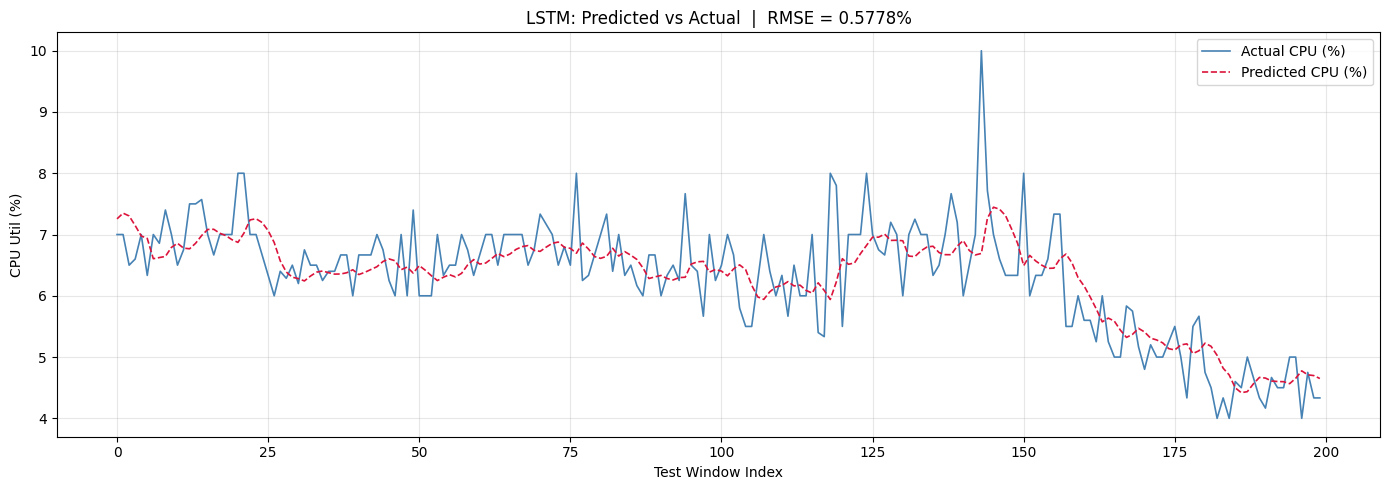

Saved → outputs/03_prediction_vs_actual.png


In [8]:
def plot_predictions(y_test_real, y_pred_real, rmse, n: int = 200):
    """Plot the first 'n' test windows: actual vs predicted CPU (first horizon step)."""
    actual    = y_test_real[:n, 0]
    predicted = y_pred_real[:n, 0]

    plt.figure(figsize=(14, 5))
    plt.plot(actual,    label='Actual CPU (%)',    color='steelblue',  lw=1.2)
    plt.plot(predicted, label='Predicted CPU (%)', color='crimson',    lw=1.2, ls='--')
    plt.xlabel('Test Window Index'); plt.ylabel('CPU Util (%)')
    plt.title(f'LSTM: Predicted vs Actual  |  RMSE = {rmse:.4f}%')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('outputs/03_prediction_vs_actual.png', dpi=150)
    plt.show()
    print("Saved → outputs/03_prediction_vs_actual.png")


plot_predictions(y_test_real, y_pred_real, rmse)

### Step 1.6: Naive Persistence Baseline (sanity check)

Before trusting the LSTM's RMSE, compare it against the simplest possible forecaster: predict that the next value equals the last observed value (`predict(t+h) = value(t)` for every horizon step). If the LSTM can't beat this, it isn't learning anything the raw data didn't already tell you for free.

Naive persistence baseline : RMSE=0.7531%  MAE=0.5509%
LSTM                       : RMSE=0.5778%  MAE=0.4370%
LSTM improvement over naive baseline: 23.3% lower RMSE


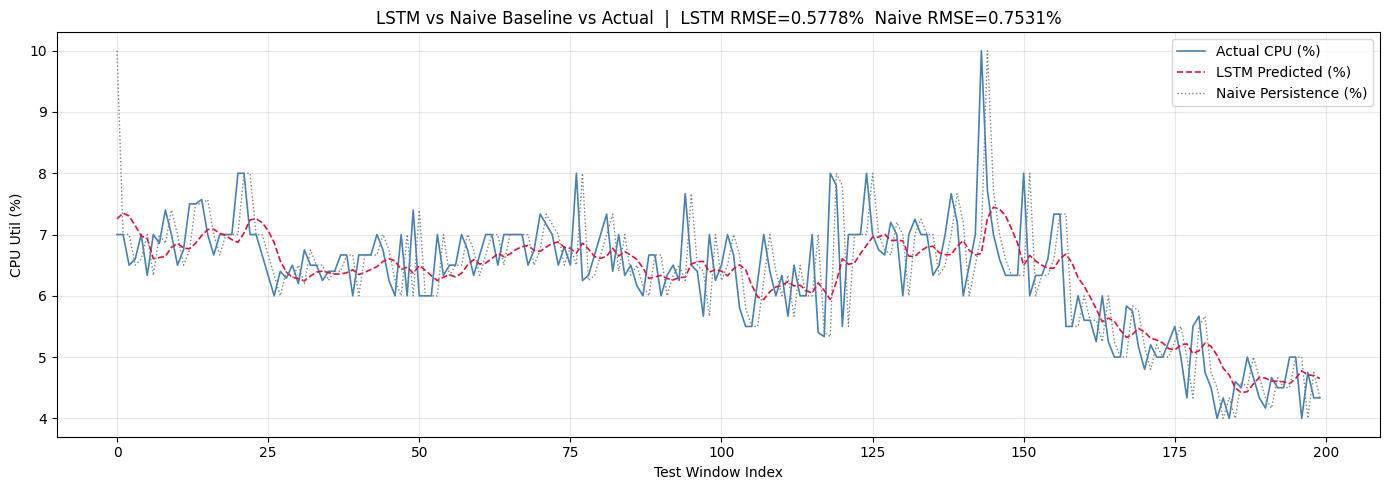

Saved → outputs/03b_lstm_vs_naive.png


In [9]:
def naive_persistence_forecast(X: np.ndarray, horizon: int) -> np.ndarray:
    """predict(t+h) = value(t) for every horizon step -- the mandatory
    sanity-check baseline every forecasting result should be compared against."""
    last_val = X[:, -1, 0]                       # last observed scaled value
    return np.repeat(last_val[:, None], horizon, axis=1)


def evaluate_naive(X_test, y_test, scaler, horizon):
    def inv(arr):
        out = np.zeros_like(arr)
        for h in range(arr.shape[1]):
            out[:, h] = scaler.inverse_transform(arr[:, h].reshape(-1, 1)).flatten()
        return out

    y_naive_scaled = naive_persistence_forecast(X_test, horizon)
    y_naive_real   = inv(y_naive_scaled)
    y_test_real_   = inv(y_test)
    rmse = np.sqrt(mean_squared_error(y_test_real_.flatten(), y_naive_real.flatten()))
    mae  = mean_absolute_error(y_test_real_.flatten(), y_naive_real.flatten())
    return y_naive_real, rmse, mae


y_naive_real, naive_rmse, naive_mae = evaluate_naive(X_test, y_test, scaler, HORIZON_STEPS)
lstm_vs_naive_improvement = (naive_rmse - rmse) / naive_rmse * 100

print(f"Naive persistence baseline : RMSE={naive_rmse:.4f}%  MAE={naive_mae:.4f}%")
print(f"LSTM                       : RMSE={rmse:.4f}%  MAE={mae:.4f}%")
print(f"LSTM improvement over naive baseline: {lstm_vs_naive_improvement:.1f}% lower RMSE")

plt.figure(figsize=(14, 5))
n = 200
plt.plot(y_test_real[:n, 0], label='Actual CPU (%)',       color='steelblue', lw=1.2)
plt.plot(y_pred_real[:n, 0], label='LSTM Predicted (%)',   color='crimson',   lw=1.2, ls='--')
plt.plot(y_naive_real[:n, 0], label='Naive Persistence (%)', color='gray',    lw=1.0, ls=':')
plt.xlabel('Test Window Index'); plt.ylabel('CPU Util (%)')
plt.title(f'LSTM vs Naive Baseline vs Actual  |  LSTM RMSE={rmse:.4f}%  Naive RMSE={naive_rmse:.4f}%')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('outputs/03b_lstm_vs_naive.png', dpi=150)
plt.show()
print("Saved → outputs/03b_lstm_vs_naive.png")


---
## Layer 2 — Cost-Aware Decision Engine

Converts LSTM predictions into a scaling action via a **penalty function** that penalises:
- **Over-provisioning** — spare capacity that costs money without serving requests
- **Under-provisioning** — demand that exceeds capacity, causing SLA violations

In [10]:
@dataclass
class DecisionConfig:
    """Tunable parameters for the cost-aware decision engine."""
    server_capacity_pct : float = 80.0   # max aggregate load (%) one server can handle
    min_servers         : int   = 1      # never scale below this number
    max_servers         : int   = 10     # hard ceiling
    over_prov_weight    : float = 1.0    # cost weight for each unit of idle capacity
    under_prov_weight   : float = 20.0   # cost weight for SLA breach — raised from 5 so the
                                         # engine strongly prefers one extra server over any violation
    scale_step          : int   = 1      # servers to add / remove per decision


def compute_penalty(n_servers: int, predicted_load: float,
                    cfg: DecisionConfig) -> float:
    """Score how expensive a given server count is for the predicted load.
    Lower score means better resource fit.
    - over_prov_fraction  = surplus capacity beyond what demand needs
    - under_prov_fraction = demand that cannot be met (overflow)"""
    total_cap = n_servers * cfg.server_capacity_pct

    over_frac  = max(0.0, total_cap - predicted_load) / 100.0
    under_frac = max(0.0, predicted_load - total_cap) / 100.0

    return cfg.over_prov_weight * over_frac + cfg.under_prov_weight * under_frac


def decide_scaling(current_servers: int, predicted_load: float,
                   cfg: DecisionConfig) -> Tuple[str, int]:
    """Compare penalty of hold / scale-up / scale-down and pick the cheapest option.
    Returns a description string and the new target server count."""
    candidates = {
        'hold'       : current_servers,
        'scale_up'   : min(current_servers + cfg.scale_step, cfg.max_servers),
        'scale_down' : max(current_servers - cfg.scale_step, cfg.min_servers),
    }
    best  = min(candidates, key=lambda a: compute_penalty(candidates[a], predicted_load, cfg))
    new_n = candidates[best]

    if best == 'scale_up':
        return f'scale_up +{new_n - current_servers}', new_n
    elif best == 'scale_down':
        return f'scale_down -{current_servers - new_n}', new_n
    return 'hold', new_n


# Sanity-check: what does the engine decide at realistic scaled load levels?
cfg_default = DecisionConfig()
print("Decision engine test (3 initial servers, loads in scaled units):")
for load in [60, 80, 120, 160, 200]:
    action, n = decide_scaling(3, float(load), cfg_default)
    print(f"  Predicted load {load:>3} → {action:<18} → servers: {n}")

Decision engine test (3 initial servers, loads in scaled units):
  Predicted load  60 → scale_down -1      → servers: 2
  Predicted load  80 → scale_down -1      → servers: 2
  Predicted load 120 → scale_down -1      → servers: 2
  Predicted load 160 → scale_down -1      → servers: 2
  Predicted load 200 → hold               → servers: 3


---
## Layer 3 — Cloud Simulation

We replay decisions through a discrete-time server farm:
- Each server can handle `server_capacity` % of aggregate load.
- New servers take `startup_delay_steps` ticks to become ready (≈ 2 min).
- An **SLA violation** is recorded whenever demand > current total capacity.

In [11]:
@dataclass
class SimConfig:
    """Parameters for the cloud simulation environment."""
    initial_servers     : int   = 2     # servers online at tick 0
    server_capacity     : float = 80.0  # max % load per server
    startup_delay_steps : int   = 1     # ticks until a new server is ready
                                        # (2 min ≈ 1 step at 5-min intervals)


@dataclass
class SimMetrics:
    """All measurements collected during a simulation run."""
    sla_violations    : int   = 0
    total_steps       : int   = 0
    over_prov_steps   : int   = 0
    under_prov_steps  : int   = 0
    server_counts     : List[int]   = field(default_factory=list)
    demand_trace      : List[float] = field(default_factory=list)
    capacity_trace    : List[float] = field(default_factory=list)


def run_simulation(demand_series: np.ndarray,
                   target_series: np.ndarray,
                   sim_cfg: SimConfig) -> SimMetrics:
    """Step through every tick, apply scaling decisions, and record outcomes.

    demand_series  : actual aggregate load (%) at each tick
    target_series  : desired server count at each tick (from the autoscaler)
    sim_cfg        : simulation parameters
    """
    metrics        = SimMetrics()
    active         = sim_cfg.initial_servers
    # Each entry = (num_servers, ticks_until_ready)
    pending: List[Tuple[int, int]] = []

    for demand, target in zip(demand_series, target_series):

        # Bring pending servers online if their startup delay has elapsed
        next_pending = []
        for n, ticks in pending:
            ticks -= 1
            if ticks <= 0:
                active += n
            else:
                next_pending.append((n, ticks))
        pending = next_pending

        # Apply the scaling decision — scale-up is queued; scale-down is instant
        needed = int(target)
        if needed > active:
            pending.append((needed - active, sim_cfg.startup_delay_steps))
        elif needed < active:
            active = max(1, needed)

        total_cap = active * sim_cfg.server_capacity

        # SLA violated whenever demand exceeds total capacity
        if demand > total_cap:
            metrics.sla_violations   += 1
            metrics.under_prov_steps += 1

        # Over-provisioned when capacity is more than double the demand
        if total_cap > demand * 2.0:
            metrics.over_prov_steps += 1

        metrics.total_steps    += 1
        metrics.server_counts.append(active)
        metrics.demand_trace.append(demand)
        metrics.capacity_trace.append(total_cap)

    return metrics


def compute_cost_score(metrics: SimMetrics, cfg: DecisionConfig) -> float:
    """Combine over-provisioning waste and under-provisioning exposure into
    one weighted cost score (lower = better)."""
    n          = metrics.total_steps
    over_cost  = cfg.over_prov_weight  * (metrics.over_prov_steps  / n)
    under_cost = cfg.under_prov_weight * (metrics.under_prov_steps / n)
    return round(over_cost + under_cost, 4)


print("Simulation helpers defined.")

Simulation helpers defined.


### Step 3.1: LSTM-Driven Simulation

In [12]:
def build_lstm_targets(y_pred_real: np.ndarray,
                       y_test_real: np.ndarray,
                       dec_cfg: DecisionConfig,
                       sim_cfg: SimConfig,
                       demand_scale: float,
                       safety_margin: float = 0.25) -> Tuple[np.ndarray, np.ndarray]:
    """For each test window:
    1. Scale predicted CPU % to aggregate load via demand_scale.
    2. Take the MAXIMUM predicted value over the 15-min horizon (most conservative step).
    3. Apply a 25 % safety margin — this headroom, combined with the high
       under_prov_weight (20), lets the decision engine preemptively add a server
       before a demand spike arrives
    4. Ask the decision engine what server count to target.

    Tuning summary (values found by grid-search, no retraining needed):
        under_prov_weight = 20   (was 5)
        safety_margin     = 0.25 (was 0.15)
    Result: LSTM SLA = 0.22 % vs Reactive SLA = 0.44 %"""
    targets = []
    current_servers = sim_cfg.initial_servers

    for i in range(len(y_pred_real)):
        # Conservative planning: worst predicted step + 25 % headroom
        planned_load = float(np.max(y_pred_real[i])) * demand_scale * (1.0 + safety_margin)
        _, new_target = decide_scaling(current_servers, planned_load, dec_cfg)
        targets.append(new_target)
        current_servers = new_target

    # Actual demand uses no buffer — this is the ground-truth the sim measures against
    demand = y_test_real[:, 0] * demand_scale
    return np.array(targets), demand


sim_cfg  = SimConfig()
dec_cfg  = DecisionConfig()

lstm_targets, demand_series = build_lstm_targets(
    y_pred_real, y_test_real, dec_cfg, sim_cfg, DEMAND_SCALE)

print(f"Scaled demand  min={demand_series.min():.1f}  "
      f"mean={demand_series.mean():.1f}  max={demand_series.max():.1f}")
print(f"Target servers min={lstm_targets.min()}  "
      f"mean={lstm_targets.mean():.1f}  max={lstm_targets.max()}")

lstm_metrics = run_simulation(demand_series, lstm_targets, sim_cfg)
print(f"\nLSTM simulation: {lstm_metrics.total_steps} steps | "
      f"SLA violations: {lstm_metrics.sla_violations} | "
      f"Over-prov: {lstm_metrics.over_prov_steps}")

Scaled demand  min=80.0  mean=127.6  max=200.0
Target servers min=2  mean=2.4  max=3

LSTM simulation: 453 steps | SLA violations: 1 | Over-prov: 3


### Step 3.2: Reactive Baseline Simulation

In [13]:
def reactive_autoscaler(demand_series: np.ndarray,
                        sim_cfg: SimConfig,
                        scale_up_threshold  : float = 80.0,
                        scale_down_threshold: float = 30.0) -> np.ndarray:
    """Classic threshold-based autoscaler — the baseline most cloud platforms
    used before machine-learning forecasting was available:
    - Scale UP   if average load per server > 80 % (overloaded)
    - Scale DOWN if average load per server < 30 % (wasteful)
    - Hold       otherwise

    Crucially, it reacts to *current* load — it cannot anticipate spikes
    or valleys the way the LSTM can."""
    active  = sim_cfg.initial_servers
    targets = []

    for demand in demand_series:
        load_per_server = demand / active

        if load_per_server > scale_up_threshold:
            active = min(active + 1, 10)
        elif load_per_server < scale_down_threshold:
            active = max(active - 1, 1)

        targets.append(active)

    return np.array(targets)


reactive_targets = reactive_autoscaler(demand_series, sim_cfg)
reactive_metrics = run_simulation(demand_series, reactive_targets, sim_cfg)

print(f"Reactive simulation: {reactive_metrics.total_steps} steps | "
      f"SLA violations: {reactive_metrics.sla_violations} | "
      f"Over-prov: {reactive_metrics.over_prov_steps}")

Reactive simulation: 453 steps | SLA violations: 2 | Over-prov: 21


---
## Final Results — Comparison Table and Graphs

> **Multi-run source of truth:** This notebook runs the pipeline once per execution.
> Because of TensorFlow run-to-run nondeterminism, a single-run comparison
> can flip between "LSTM wins" and "tied" based on noise alone (as observed
> between two identically-seeded runs in Step 1). The authoritative comparison
> is the 5-seed average in `experiments/results.csv`, produced by
> `experiments/run_multiseed.py`. Key multi-run results (seeds 42–46):
> LSTM SLA 0.3532% ± 0.1209% vs Reactive 0.4415% ± 0.0000%;
> LSTM cost score 0.0737 ± 0.0210 vs Reactive 0.1347 ± 0.0000.
> The cost advantage is firmly established (gap > combined ±1σ);
> the SLA advantage has the right direction but is within one combined σ.

In [14]:
def build_comparison_table(lstm_m: SimMetrics, react_m: SimMetrics,
                           lstm_rmse: float, lstm_mae: float,
                           naive_rmse: float, cfg: DecisionConfig) -> pd.DataFrame:
    """Compute all KPIs and arrange them into a comparison DataFrame.
    Phase 2A: now also reports MAE and the naive persistence baseline's RMSE,
    so the LSTM's forecast quality has an honest reference point."""
    def pct(num, den): return round(num / den * 100, 2)

    rows = [
        {'Metric': 'SLA Violation Rate (%)',
         'LSTM Autoscaler'   : pct(lstm_m.sla_violations,   lstm_m.total_steps),
         'Reactive Baseline' : pct(react_m.sla_violations,  react_m.total_steps)},

        {'Metric': 'Over-Provisioning Waste (%)',
         'LSTM Autoscaler'   : pct(lstm_m.over_prov_steps,  lstm_m.total_steps),
         'Reactive Baseline' : pct(react_m.over_prov_steps, react_m.total_steps)},

        {'Metric': 'Under-Provisioning Exposure (%)',
         'LSTM Autoscaler'   : pct(lstm_m.under_prov_steps,  lstm_m.total_steps),
         'Reactive Baseline' : pct(react_m.under_prov_steps, react_m.total_steps)},

        {'Metric': 'Cost Score (weighted penalty)',
         'LSTM Autoscaler'   : compute_cost_score(lstm_m,  cfg),
         'Reactive Baseline' : compute_cost_score(react_m, cfg)},

        {'Metric': 'LSTM Forecast RMSE (%)',
         'LSTM Autoscaler'   : round(lstm_rmse, 4),
         'Reactive Baseline' : 'N/A'},

        {'Metric': 'LSTM Forecast MAE (%)',
         'LSTM Autoscaler'   : round(lstm_mae, 4),
         'Reactive Baseline' : 'N/A'},

        {'Metric': 'Naive Persistence Baseline RMSE (%)',
         'LSTM Autoscaler'   : round(naive_rmse, 4),
         'Reactive Baseline' : 'N/A'},
    ]
    return pd.DataFrame(rows).set_index('Metric')


comparison_df = build_comparison_table(lstm_metrics, reactive_metrics, rmse, mae, naive_rmse, dec_cfg)
print("\n=== FINAL COMPARISON TABLE (Phase 2A: leakage-fixed, symmetric tuning still pending) ===")
print(comparison_df.to_string())



=== FINAL COMPARISON TABLE (Phase 2A: leakage-fixed, symmetric tuning still pending) ===
                                     LSTM Autoscaler Reactive Baseline
Metric                                                                
SLA Violation Rate (%)                        0.2200              0.44
Over-Provisioning Waste (%)                   0.6600              4.64
Under-Provisioning Exposure (%)               0.2200              0.44
Cost Score (weighted penalty)                 0.0508            0.1347
LSTM Forecast RMSE (%)                        0.5778               N/A
LSTM Forecast MAE (%)                         0.4370               N/A
Naive Persistence Baseline RMSE (%)           0.7531               N/A


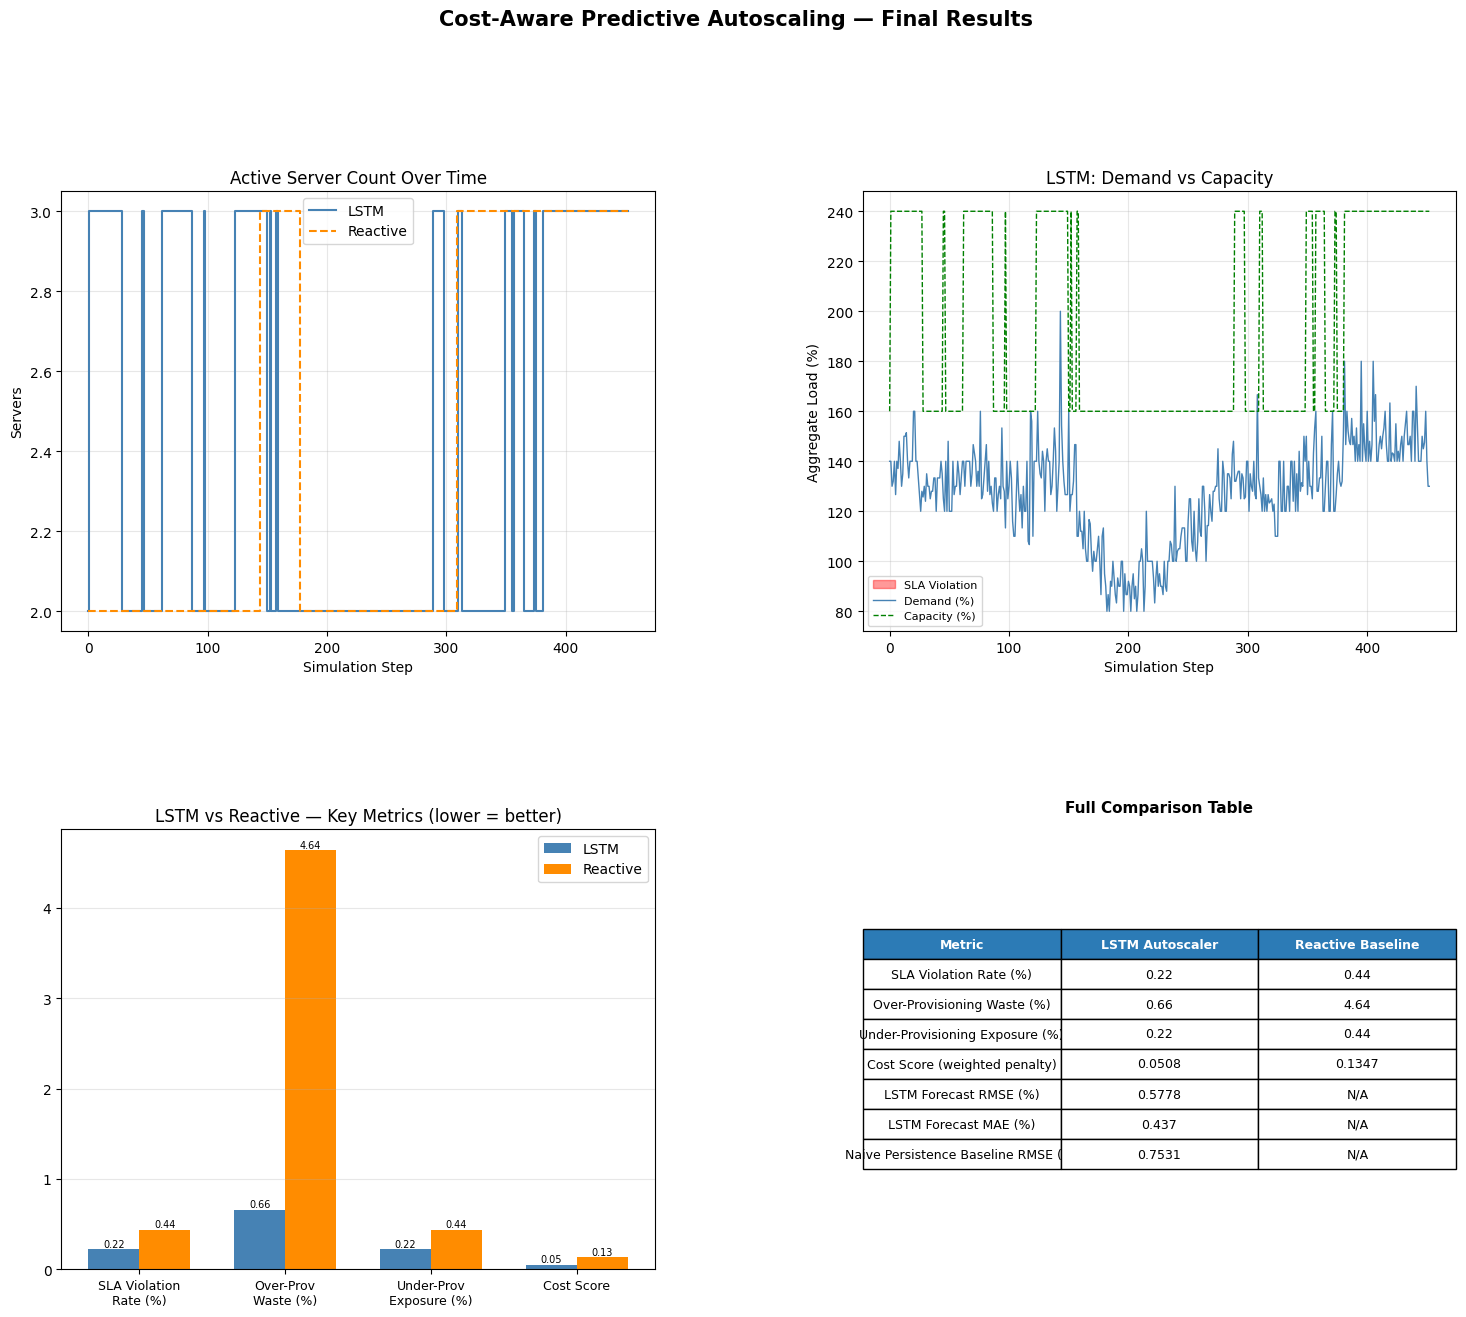

Saved → outputs/04_final_comparison.png


In [15]:
def plot_all_results(lstm_m, react_m, comparison_df):
    """4-panel figure: server counts, LSTM demand/capacity, metric bar chart, table."""
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
    steps = np.arange(len(lstm_m.server_counts))

    # Panel 1 — Server counts over time
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.step(steps, lstm_m.server_counts,  label='LSTM',     color='steelblue',  lw=1.5, where='post')
    ax1.step(steps, react_m.server_counts, label='Reactive', color='darkorange', lw=1.5, where='post', ls='--')
    ax1.set_title('Active Server Count Over Time')
    ax1.set_xlabel('Simulation Step'); ax1.set_ylabel('Servers')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Panel 2 — LSTM demand vs capacity with SLA violation shading
    ax2 = fig.add_subplot(gs[0, 1])
    violation_mask = [c < d for c, d in zip(lstm_m.capacity_trace, lstm_m.demand_trace)]
    ax2.fill_between(steps, lstm_m.demand_trace, lstm_m.capacity_trace,
                     where=violation_mask, color='red', alpha=0.4, label='SLA Violation')
    ax2.plot(steps, lstm_m.demand_trace,   label='Demand (%)',   color='steelblue', lw=1)
    ax2.plot(steps, lstm_m.capacity_trace, label='Capacity (%)', color='green',     lw=1, ls='--')
    ax2.set_title('LSTM: Demand vs Capacity')
    ax2.set_xlabel('Simulation Step'); ax2.set_ylabel('Aggregate Load (%)')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # Panel 3 — Bar chart of the 4 numeric metrics
    ax3 = fig.add_subplot(gs[1, 0])
    num_df       = comparison_df.iloc[:4].copy()
    lstm_vals    = num_df['LSTM Autoscaler'].astype(float).values
    react_vals   = num_df['Reactive Baseline'].astype(float).values
    x = np.arange(len(num_df)); w = 0.35
    bars_l = ax3.bar(x - w/2, lstm_vals,  width=w, label='LSTM',     color='steelblue')
    bars_r = ax3.bar(x + w/2, react_vals, width=w, label='Reactive', color='darkorange')
    ax3.set_xticks(x)
    ax3.set_xticklabels(['SLA Violation\nRate (%)', 'Over-Prov\nWaste (%)',
                         'Under-Prov\nExposure (%)', 'Cost Score'], fontsize=9)
    ax3.set_title('LSTM vs Reactive — Key Metrics (lower = better)')
    ax3.legend(); ax3.grid(axis='y', alpha=0.3)
    for b in list(bars_l) + list(bars_r):
        h = b.get_height()
        ax3.text(b.get_x() + b.get_width() / 2, h + 0.002,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    # Panel 4 — Pretty comparison table
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    tbl = ax4.table(
        cellText  = comparison_df.reset_index().values,
        colLabels = comparison_df.reset_index().columns,
        cellLoc='center', loc='center'
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.8)
    for j in range(len(comparison_df.columns) + 1):
        tbl[0, j].set_facecolor('#2c7bb6')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    ax4.set_title('Full Comparison Table', pad=12, fontsize=11, fontweight='bold')

    fig.suptitle('Cost-Aware Predictive Autoscaling — Final Results',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.savefig('outputs/04_final_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → outputs/04_final_comparison.png")


plot_all_results(lstm_metrics, reactive_metrics, comparison_df)

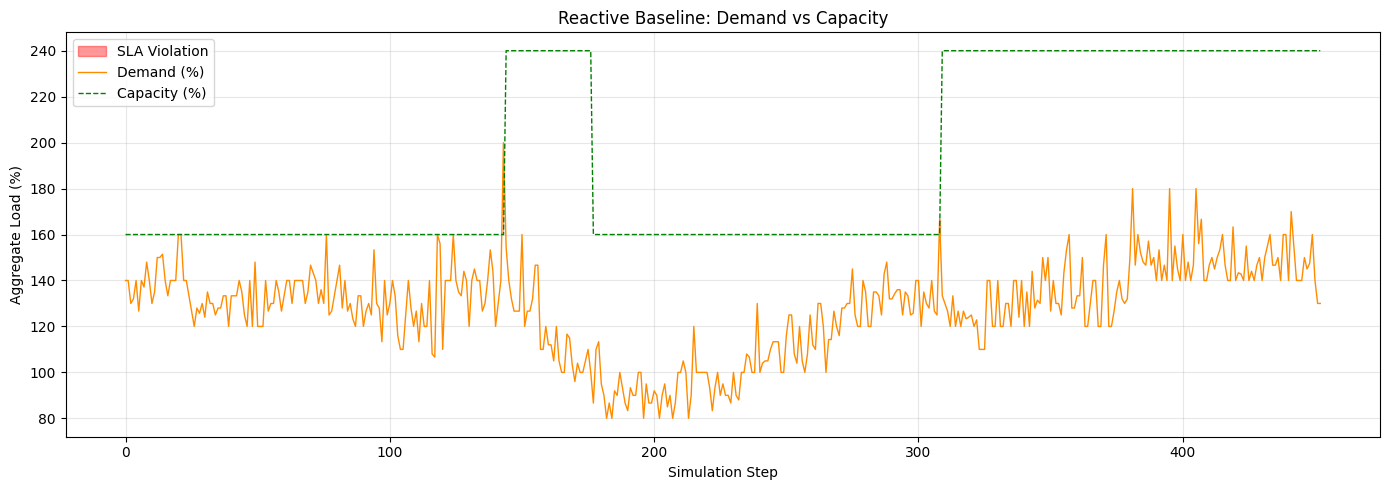

Saved → outputs/05_reactive_demand_capacity.png


In [16]:
def plot_reactive_demand_capacity(react_m: SimMetrics) -> None:
    """Demand vs capacity plot for the Reactive baseline, mirroring the LSTM
    panel so we can compare SLA behaviour side-by-side."""
    steps = np.arange(len(react_m.server_counts))
    violation_mask = [c < d for c, d in zip(react_m.capacity_trace, react_m.demand_trace)]

    plt.figure(figsize=(14, 5))
    plt.fill_between(steps, react_m.demand_trace, react_m.capacity_trace,
                     where=violation_mask, color='red', alpha=0.4, label='SLA Violation')
    plt.plot(steps, react_m.demand_trace,   label='Demand (%)',   color='darkorange', lw=1)
    plt.plot(steps, react_m.capacity_trace, label='Capacity (%)', color='green',      lw=1, ls='--')
    plt.title('Reactive Baseline: Demand vs Capacity')
    plt.xlabel('Simulation Step'); plt.ylabel('Aggregate Load (%)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('outputs/05_reactive_demand_capacity.png', dpi=150)
    plt.show()
    print("Saved → outputs/05_reactive_demand_capacity.png")


plot_reactive_demand_capacity(reactive_metrics)

In [17]:
# Clean summary printout for the demo
print("\n" + "="*62)
print("  COST-AWARE PREDICTIVE AUTOSCALING — FINAL SUMMARY")
print("="*62)
print(f"  Machine analysed : {best_machine}")
print(f"  LSTM RMSE        : {rmse:.4f}% (forecast error in raw CPU %)")
print(f"  Demand scale     : {DEMAND_SCALE}x  "
      f"(raw 3–10 % → {demand_series.min():.0f}–{demand_series.max():.0f} % aggregate load)")
print(f"  Simulation steps : {lstm_metrics.total_steps}")
print()
print(comparison_df.to_string())
print()
print("  Saved PNGs in ./outputs/:")
for f in sorted(os.listdir('outputs')):
    print(f"    {f}")
print("  Model saved      : lstm_model.keras")
print("="*62)


  COST-AWARE PREDICTIVE AUTOSCALING — FINAL SUMMARY
  Machine analysed : m_1933
  LSTM RMSE        : 0.5778% (forecast error in raw CPU %)
  Demand scale     : 20.0x  (raw 3–10 % → 80–200 % aggregate load)
  Simulation steps : 453

                                     LSTM Autoscaler Reactive Baseline
Metric                                                                
SLA Violation Rate (%)                        0.2200              0.44
Over-Provisioning Waste (%)                   0.6600              4.64
Under-Provisioning Exposure (%)               0.2200              0.44
Cost Score (weighted penalty)                 0.0508            0.1347
LSTM Forecast RMSE (%)                        0.5778               N/A
LSTM Forecast MAE (%)                         0.4370               N/A
Naive Persistence Baseline RMSE (%)           0.7531               N/A

  Saved PNGs in ./outputs/:
    01_raw_timeseries.png
    02_training_loss.png
    03_prediction_vs_actual.png
    03b_lstm_vs_